# Skills → 24 Titles **plus `__other__`** — the full router model (M19/W3)

The sibling of `skills_to_24_titles.ipynb`, with the one capability that model
lacks: **an honest rejection class**. `__other__` is trained on real
non-engineering lang-uk CVs (Marketing/HR/Sales/Support/Recruiting/…), so a CV
outside the covered engineering space gets `__other__` instead of a confident
wrong title — and the ladder's LLM fallback (which knows all 59 canonical
titles) becomes a true last resort.

Per the user's decision there is **no synthetic tail data**: the 35 canonical
roles with zero real examples anywhere stay out of the label space; such CVs
route to `__other__`/low-confidence → LLM. (Measured reality check: the shipped
59-class text classifier never actually predicts those roles either — its tail
classes are nominal.)

Deterministic (seed 42), checkpointed inputs, runs top-to-bottom.

In [1]:
import os, sys, warnings
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
os.environ.setdefault('MONGO_URI', 'mongodb://localhost:27017/careerlens')
if os.path.basename(os.getcwd()) == 'final':     # notebook lives in ds/final;
    os.chdir(os.path.join('..', 'model'))        # code + data stay in ds/model
sys.path.insert(0, os.path.abspath('.'))
from pymongo import MongoClient
from taxonomy import CANONICAL_TITLES, OTHER_LABEL
from skillner_utils import identity               # module-level: artifacts stay loadable

client = MongoClient(os.environ['MONGO_URI'])
db = client['careerlens']
CV_SKILLS, MASTER_SKILLS, OTHER_SKILLS = 'lang-uk-cv-skills', 'master-resumes-skills', 'lang-uk-cv-other-skills'
print({c: db[c].estimated_document_count() for c in (CV_SKILLS, MASTER_SKILLS, OTHER_SKILLS)})

def doc_skills(doc):
    seen = set()
    sk = doc.get('skills') or {}
    for m in sk.get('full_matches', []):
        v = (m.get('doc_node_value') or '').lower().strip()
        if len(v) >= 3: seen.add(v)
    for m in sk.get('ngram_matches', []):
        v = (m.get('doc_node_value') or '').lower().strip()
        if len(v) >= 3 and float(m.get('score', 0)) >= 0.9: seen.add(v)
    return seen

def load_domain(coll_name):
    rows = []
    for doc in db[coll_name].find({}, {'og_title': 1, 'skills': 1}):
        s = doc_skills(doc)
        if len(s) >= 3:
            rows.append({'label': doc['og_title'], 'skills': s})
    return pd.DataFrame(rows)

{'lang-uk-cv-skills': 11776, 'master-resumes-skills': 4792, 'lang-uk-cv-other-skills': 1750}


## 1. Data — three sources, one label space (24 + `__other__`)

Same corpora as the 24-model plus the non-engineering sample. The tiny
`__other__` slice inside master_resumes (19 docs) is folded in too — now that
the class has real mass it no longer risks memorization. Leakage guard
unchanged (canonical title names never appear as skill features).

In [2]:
df_cvs = load_domain(CV_SKILLS)
df_master = load_domain(MASTER_SKILLS)          # includes its 19 __other__ docs this time
df_other = load_domain(OTHER_SKILLS)
LEAK = {t.lower() for t in CANONICAL_TITLES} | {t.lower() + 's' for t in CANONICAL_TITLES}
for df in (df_cvs, df_master, df_other):
    df['skills'] = df['skills'].map(lambda s: {x for x in s if x not in LEAK})
all_df = pd.concat([df_cvs, df_master, df_other], ignore_index=True)
all_df = all_df[all_df.skills.map(len) >= 3].reset_index(drop=True)
print(f'combined: {len(all_df):,} docs, {all_df.label.nunique()} classes '
      f'(__other__: {(all_df.label == OTHER_LABEL).sum():,})')

combined: 16,891 docs, 25 classes (__other__: 1,477)


## 2. Balance + train (cap 600 per class, `class_weight='balanced'`)

Identical recipe to the 24-model — frequency must not buy weight. `__other__`
obeys the same cap as everyone else.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

CLASS_CAP = 600
rng = np.random.RandomState(42)
parts = [g.sample(CLASS_CAP, random_state=rng) if len(g) > CLASS_CAP else g
         for _, g in all_df.groupby('label')]
df_bal = pd.concat(parts, ignore_index=True)
print(f'balanced: {len(df_bal):,} docs, {df_bal.label.nunique()} classes')

vec = CountVectorizer(analyzer=identity, min_df=5, binary=True)
X = vec.fit_transform(list(df_bal.skills))
le = LabelEncoder()
y = le.fit_transform(df_bal.label.to_numpy(dtype=object))
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced')
model.fit(Xtr, ytr)
proba = model.predict_proba(Xte)
pred = proba.argmax(1)
top3 = np.argsort(-proba, axis=1)[:, :3]
top3_acc = np.mean([yt in row for yt, row in zip(yte, top3)])
train_acc = accuracy_score(ytr, model.predict(Xtr))
test_acc = accuracy_score(yte, pred)
print(f'25-class logreg: acc={test_acc:.3f} (train {train_acc:.3f}) '
      f'top3={top3_acc:.3f} macroF1={f1_score(yte, pred, average="macro"):.3f} '
      f'({X.shape[1]} features)')

mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, early_stopping=True, random_state=42)
mlp.fit(Xtr, ytr)
mpred = mlp.predict_proba(Xte).argmax(1)
print(f'25-class mlp:    acc={accuracy_score(yte, mpred):.3f} '
      f'(train {accuracy_score(ytr, mlp.predict(Xtr)):.3f}) '
      f'macroF1={f1_score(yte, mpred, average="macro"):.3f}')

balanced: 9,206 docs, 25 classes


25-class logreg: acc=0.828 (train 0.943) top3=0.945 macroF1=0.887 (2265 features)


25-class mlp:    acc=0.838 (train 0.950) macroF1=0.892


In [4]:
# The class that matters most here - how precise/recall-y is the rejection?
rep = classification_report(yte, pred, target_names=le.classes_, output_dict=True, zero_division=0)
other_row = rep[OTHER_LABEL]
print(f"__other__ on held-out: precision={other_row['precision']:.3f} "
      f"recall={other_row['recall']:.3f} f1={other_row['f1-score']:.3f} "
      f"(n={int(other_row['support'])})")
per_class = (pd.DataFrame(rep).T
             .drop(index=['accuracy', 'macro avg', 'weighted avg'])
             .sort_values('f1-score'))
per_class[['precision', 'recall', 'f1-score', 'support']].round(3)

__other__ on held-out: precision=0.662 recall=0.767 f1=0.710 (n=120)


,precision,recall,f1-score,support
Backend Developer,0.708,0.667,0.687,120.0
Product Manager,0.697,0.708,0.702,120.0
__other__,0.662,0.767,0.710,120.0
Machine Learning Engineer,0.607,0.881,0.718,42.0
Frontend Developer,0.759,0.733,0.746,120.0
Software Engineer,0.814,0.692,0.748,120.0
Data Engineer,0.814,0.767,0.790,120.0
Data Scientist,0.813,0.833,0.823,120.0
Java Developer,0.829,0.850,0.840,120.0
C++ Developer,0.847,0.833,0.840,120.0


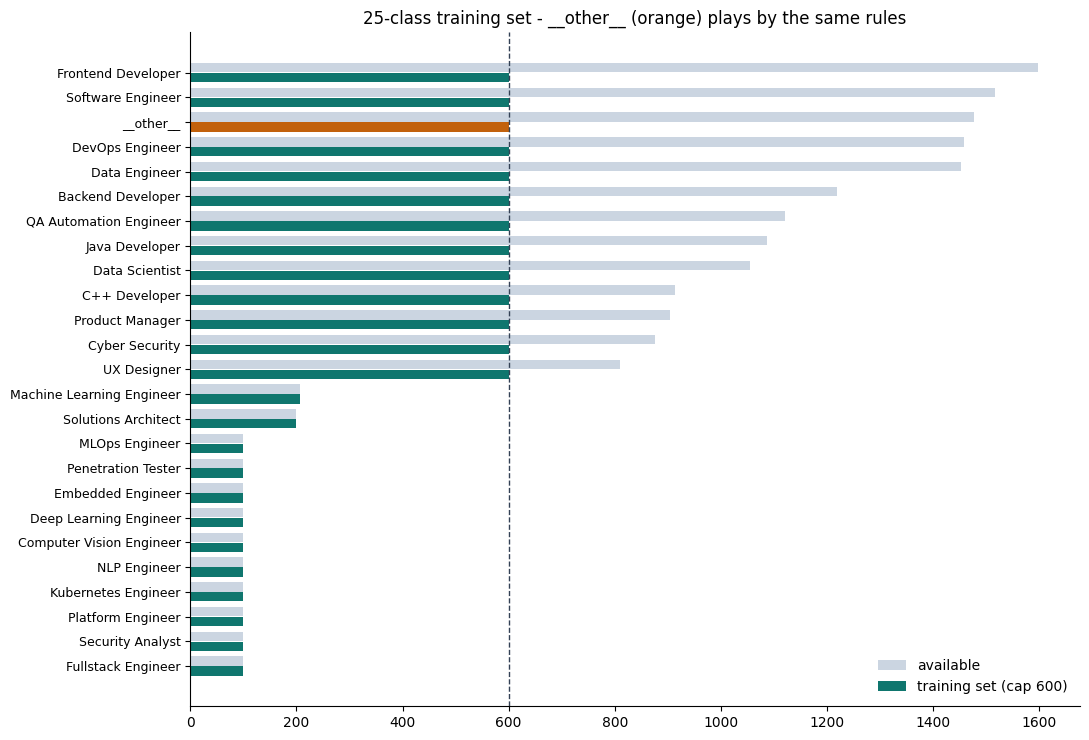

In [5]:
C_MAIN, C_MUTED, C_OTHER = '#0f766e', '#cbd5e1', '#c2610c'
before = all_df.label.value_counts(); after = df_bal.label.value_counts()
order = before.sort_values(ascending=True).index
fig, ax = plt.subplots(figsize=(11, 7.5))
ypos = np.arange(len(order))
colors = [C_OTHER if l == OTHER_LABEL else C_MAIN for l in order]
ax.barh(ypos + 0.2, [before[l] for l in order], height=0.38, color=C_MUTED, label='available')
ax.barh(ypos - 0.2, [after[l] for l in order], height=0.38, color=colors, label='training set (cap 600)')
ax.axvline(600, color='#334155', linewidth=1, linestyle='--')
ax.set_yticks(ypos, order, fontsize=9)
ax.set_title('25-class training set - __other__ (orange) plays by the same rules')
ax.legend(frameon=False, loc='lower right'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

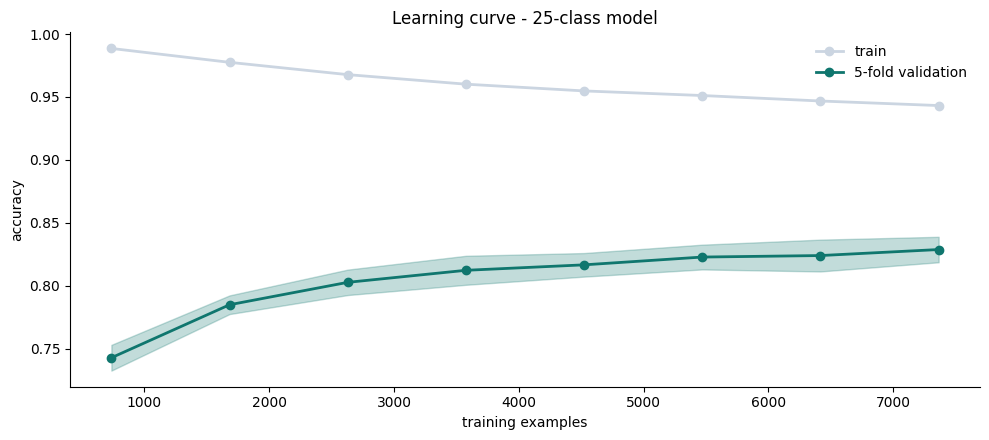

final: train 0.943 vs validation 0.829 (gap 0.114)


In [6]:
sizes, tr_s, va_s = learning_curve(
    LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced'),
    X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8), scoring='accuracy',
    shuffle=True, random_state=42, n_jobs=1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(sizes, tr_s.mean(1), color=C_MUTED, marker='o', linewidth=2, label='train')
ax.plot(sizes, va_s.mean(1), color=C_MAIN, marker='o', linewidth=2, label='5-fold validation')
ax.fill_between(sizes, va_s.mean(1) - va_s.std(1), va_s.mean(1) + va_s.std(1), color=C_MAIN, alpha=0.25)
ax.set_title('Learning curve - 25-class model'); ax.set_xlabel('training examples'); ax.set_ylabel('accuracy')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'final: train {tr_s.mean(1)[-1]:.3f} vs validation {va_s.mean(1)[-1]:.3f} '
      f'(gap {tr_s.mean(1)[-1] - va_s.mean(1)[-1]:.3f})')

## 3. The real test — all 32 authentic CVs

Now every fixture has a defined expectation: engineering-in-coverage CVs must
hit an acceptable title, the 5 `none` fixtures must land in `__other__`, and
tail-role CVs *should* ideally reject rather than confabulate (counted
separately - rejection routes them to the LLM, which is the designed path).

In [7]:
import json, fitz
from extract_skills import build_skill_extractor, extract_skills_from_text
FIXTURES = os.path.abspath(os.path.join('..', '..', 'test-fixtures', 'authentic-cvs'))
manifest = json.load(open(os.path.join(FIXTURES, 'manifest.json'), encoding='utf-8'))['cvs']
extractor = build_skill_extractor()

def pdf_text(p):
    with fitz.open(p) as d:
        return '\n'.join(pg.get_text() for pg in d)

texts, cv_skills = {}, {}
for e in manifest:
    t = pdf_text(os.path.join(FIXTURES, 'pdfs', e['file']))
    texts[e['file']] = t
    raw = extract_skills_from_text(extractor, t[:20000])
    cv_skills[e['file']] = {x for x in doc_skills({'skills': raw}) if x not in LEAK}
print('extracted skills for', len(cv_skills), 'CVs')

loading full_matcher ...


loading abv_matcher ...
loading full_uni_matcher ...


loading low_form_matcher ...


loading token_matcher ...


extracted skills for 32 CVs


In [8]:
COVERED = set(le.classes_) - {OTHER_LABEL}
rows = []
for e in manifest:
    f = e['file']
    acceptable = set(e['acceptable_titles'] or [])
    is_none = e['true_title'] == 'none'
    in_cov = bool(acceptable & COVERED)
    p = model.predict_proba(vec.transform([cv_skills[f]]))[0]
    order = np.argsort(-p)
    predicted, conf = le.classes_[order[0]], float(p[order[0]])
    if is_none:
        outcome = 'rejected ✓' if predicted == OTHER_LABEL else f'NOT rejected ({predicted})'
        correct = predicted == OTHER_LABEL
    elif in_cov:
        correct = predicted in acceptable
        outcome = 'correct' if correct else f'wrong ({predicted})'
    else:  # tail engineering role - rejection is the designed route to the LLM
        correct = None
        outcome = ('routed to LLM ✓ (__other__)' if predicted == OTHER_LABEL
                   else f'nearest-family ({predicted})')
    rows.append({'file': f, 'true': e['true_title'], 'pred': predicted,
                 'conf': round(conf, 3), 'in_coverage': in_cov, 'is_none': is_none,
                 'correct': correct, 'outcome': outcome})
res = pd.DataFrame(rows)
cov = res[res.correct.notna() & ~res.is_none]
nones = res[res.is_none]
tails = res[res.correct.isna() & ~res.is_none]
print(f'in-coverage: {int(cov.correct.sum())}/{len(cov)} ({cov.correct.mean():.0%})')
print(f"'none' fixtures rejected: {int(nones.correct.sum())}/{len(nones)}")
print(f'tail-role CVs routed to __other__->LLM: '
      f"{int((tails.pred == OTHER_LABEL).sum())}/{len(tails)}")
pd.set_option('display.max_colwidth', 90)
res[['file', 'true', 'pred', 'conf', 'outcome']]

in-coverage: 16/25 (64%)
'none' fixtures rejected: 1/5
tail-role CVs routed to __other__->LLM: 0/2


,file,true,pred,conf,outcome
0,backend-senior-strong_Daniel-Peretz.pdf,Backend Developer,Software Engineer,0.762,wrong (Software Engineer)
1,frontend-mid-strong_Noa-Shapiro.pdf,Frontend Developer,Frontend Developer,0.985,correct
2,devops-senior-strong_Alex-Vaisman.pdf,DevOps Engineer,DevOps Engineer,1.000,correct
3,datascientist-mid-strong_Maya-Berkovich.pdf,Data Scientist,Data Scientist,0.976,correct
4,qa-automation-mid-mid_Yossi-Alfasi.pdf,QA Automation Engineer,QA Automation Engineer,1.000,correct
5,ml-senior-strong_Amir-Dahan.pdf,Machine Learning Engineer,Data Scientist,0.997,wrong (Data Scientist)
6,java-senior-mid_Marina-Feldman.pdf,Java Developer,Java Developer,1.000,correct
7,software-mid-mid_Tomer-Azulay.pdf,Software Engineer,Backend Developer,0.995,wrong (Backend Developer)
8,dataeng-mid-strong_Shira-Golan.pdf,Data Engineer,Data Engineer,0.994,correct
9,fullstack-mid-ambiguous_Omri-Katz.pdf,Fullstack Engineer,Backend Developer,0.933,correct


In [9]:
# Context: the shipped text classifier's rejection on the same 5 'none' fixtures
import joblib
text_clf = joblib.load('text_to_job_title_classifier.joblib')
labels_t = list(text_clf.classes_)
oi = labels_t.index(OTHER_LABEL)
print("'none' fixtures - __other__ probability mass, ours vs shipped:")
for e in manifest:
    if e['true_title'] != 'none': continue
    p_ours = model.predict_proba(vec.transform([cv_skills[e['file']]]))[0]
    ours_other = float(p_ours[list(le.classes_).index(OTHER_LABEL)])
    shipped_other = float(text_clf.predict_proba([texts[e['file']]])[0][oi])
    print(f"  {e['file']:45s} ours={ours_other:.2f} shipped={shipped_other:.2f}")

'none' fixtures - __other__ probability mass, ours vs shipped:
  gamedev-mid-none_Ben-Harari.pdf               ours=0.03 shipped=0.00
  techwriter-mid-none_Efrat-Landau.pdf          ours=0.03 shipped=0.10
  hebrew-reject_Rotem-Bar.pdf                   ours=0.07 shipped=0.01
  hebrew-mixed-reject_Shai-Levi.pdf             ours=0.00 shipped=0.00
  scanned-image-reject_Old-Format.pdf           ours=0.15 shipped=0.02


## 4. Production artifact

In [10]:
art_path = 'skills_to_24_plus_other.joblib'
joblib.dump({'model': model, 'vectorizer': vec, 'label_encoder': le,
             'labels': sorted(COVERED) + [OTHER_LABEL],
             'trained_on': f'{CV_SKILLS} + {MASTER_SKILLS} + {OTHER_SKILLS} (cap {CLASS_CAP}, balanced)',
             'leak_guard_size': len(LEAK),
             'trained_at': datetime.now().strftime('%Y%m%d_%H%M%S')}, art_path)
print('saved', art_path, '- unpickles anywhere (analyzer imported from skillner_utils)')

saved skills_to_24_plus_other.joblib - unpickles anywhere (analyzer imported from skillner_utils)


## 5. Wrap-up

The router model: 24 covered engineering roles get direct answers; everything
else — non-engineering CVs and tail roles alike — flows to `__other__`, which in
the detection ladder means the closed-list LLM (all 59 titles) and, failing
that, the manual picker. Numbers feed the M19 report; the ladder-wiring
decision (W4) is taken with these measurements on the table.